In [19]:
# ================================
# 📘 Life Expectancy Prediction (Clean Version)
# ================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

In [20]:
# Step 1️⃣ — Load and clean data
data = pd.read_csv('C:\mechine_learning\LifeExpectancy.csv')
data = data.dropna()
data.columns = data.columns.str.strip()

# Step 2️⃣ — Select relevant columns
selected_data = data[['Year', 'GDP', 'Schooling']].dropna()

# Step 3️⃣ — Prepare features (X) and target (y)
X = selected_data[['Year', 'GDP']]
y = selected_data['Schooling']

In [21]:
# Step 4️⃣ — Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [22]:
# Step 5️⃣ — Train the model
model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [23]:
y_pred= model.predict(X_test)
mse=mean_squared_error(y_pred,y_test)
r2=r2_score(y_pred,y_test)

In [24]:
print("✅ Model trained successfully")
print(f"Mean Squared Error: {mse:.4f}")
print(f"R² Score: {r2:.4f}")

✅ Model trained successfully
Mean Squared Error: 5.9501
R² Score: -4.5981


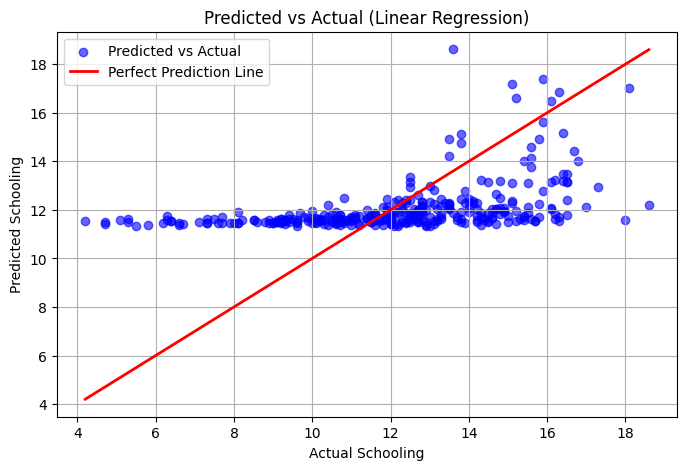

In [25]:
# Step 8️⃣ — Visualization: Predicted vs Actual
plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred, color='blue', alpha=0.6, label='Predicted vs Actual')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
         color='red', linewidth=2, label='Perfect Prediction Line')
plt.xlabel("Actual Schooling")
plt.ylabel("Predicted Schooling")
plt.title("Predicted vs Actual (Linear Regression)")
plt.legend()
plt.grid(True)
plt.show()


🎯 Predicted Schooling for 2025: 12.00 years


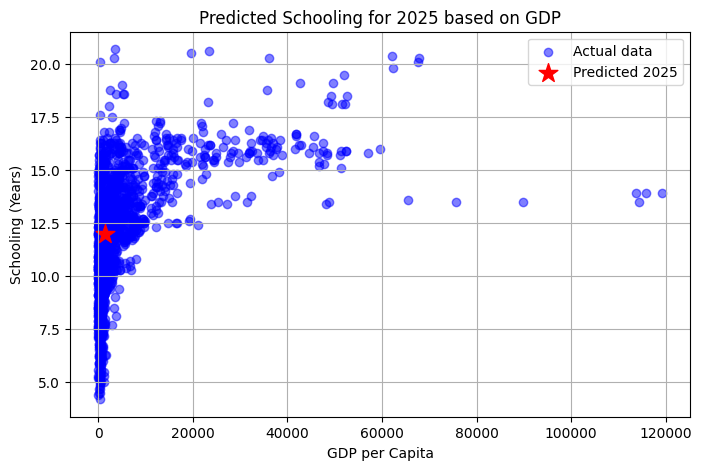

In [26]:
# Step 9️⃣ — Predict for new data
new_data = pd.DataFrame({'Year': [2025], 'GDP': [1474.1]})
predicted_y = model.predict(new_data)
print(f"🎯 Predicted Schooling for 2025: {predicted_y[0]:.2f} years")

# Step 🔟 — Visualization: GDP vs Schooling
plt.figure(figsize=(8, 5))
plt.scatter(selected_data['GDP'], selected_data['Schooling'], color='blue', alpha=0.5, label='Actual data')
plt.scatter(1474.1, predicted_y, color='red', marker='*', s=200, label='Predicted 2025')
plt.xlabel('GDP per Capita')
plt.ylabel('Schooling (Years)')
plt.title('Predicted Schooling for 2025 based on GDP')
plt.legend()
plt.grid(True)
plt.show()

In [27]:
numeric_features = selected_data.select_dtypes(include=['number'])

In [28]:
numeric_features

,Year,GDP,Schooling
0,2015,584.259210,10.1
1,2014,612.696514,10.0
2,2013,631.744976,9.9
3,2012,669.959000,9.8
4,2011,63.537231,9.5
...,...,...,...
2923,2004,454.366654,9.2
2924,2003,453.351155,9.5
2925,2002,57.348340,10.0
2926,2001,548.587312,9.8


In [29]:
x=numeric_features.iloc[:,:-1].values
y=numeric_features.iloc[:,-1].values

In [30]:
x

array([[2015.       ,  584.25921  ],
       [2014.       ,  612.696514 ],
       [2013.       ,  631.744976 ],
       ...,
       [2002.       ,   57.34834  ],
       [2001.       ,  548.587312 ],
       [2000.       ,  547.3588785]], shape=(1649, 2))

In [31]:
y

array([10.1, 10. ,  9.9, ..., 10. ,  9.8,  9.8], shape=(1649,))

In [32]:
x_test,x_train,y_test,y_train=train_test_split(x,y,test_size=0.2,) 

In [33]:
x_test

array([[2003.       ,  928.18227  ],
       [2004.       , 2632.79942  ],
       [2008.       ,   11.33678  ],
       ...,
       [2014.       , 3988.771871 ],
       [2014.       ,  571.1622759],
       [2004.       , 1217.657961 ]], shape=(1319, 2))

In [34]:
y_test

array([11.8, 12.4,  7.1, ..., 13.2,  8.4, 10.4], shape=(1319,))

In [35]:
model=LinearRegression()
model.fit(x_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [36]:
# model.predict(x_test)
y_pred=model.predict(x_test)
mse=mean_squared_error(y_test,y_pred)
r2=r2_score(y_test,y_pred)

In [37]:
print("✅ Model trained successfully")
print(f"Mean Squared Error: {mse:.4f}")
print(f"R² Score: {r2:.4f}")

✅ Model trained successfully
Mean Squared Error: 6.0121
R² Score: 0.2262


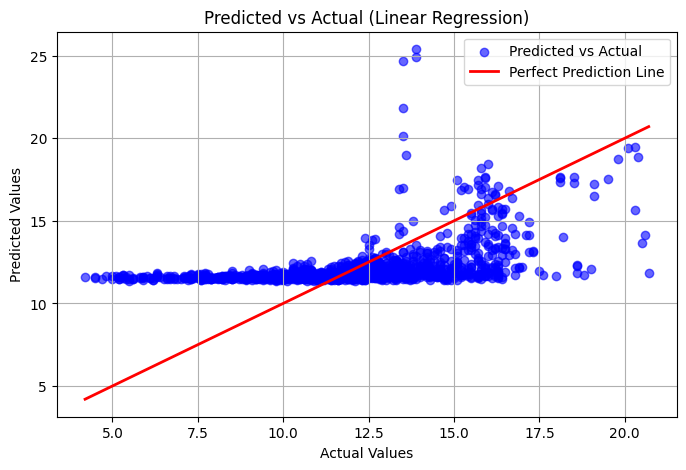

In [38]:
# Step 🔟 — Visualization
plt.figure(figsize=(8,5))
plt.scatter(y_test, y_pred, color='blue', alpha=0.6, label='Predicted vs Actual')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
         color='red', linewidth=2, label='Perfect Prediction Line')
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Predicted vs Actual (Linear Regression)")
plt.legend()
plt.grid(True)
plt.show()

In [39]:
new_data = np.array([[2025,1474.1]])  # example input matching number of features
predicted_y = model.predict(new_data)
print("Predicted Life Expectancy:", predicted_y)


Predicted Life Expectancy: [12.09303465]


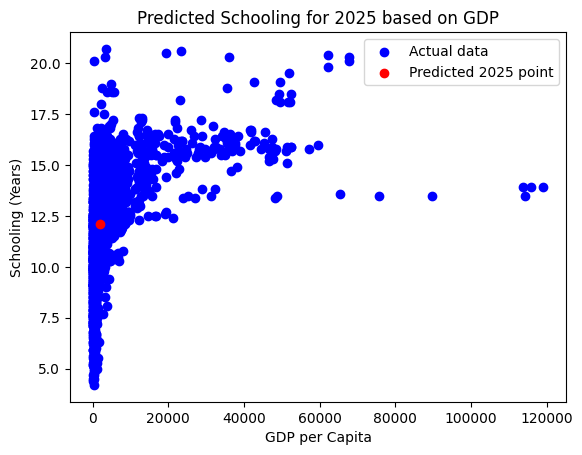

In [40]:

# Predicted vs actual
plt.scatter(data['GDP'], data['Schooling'], color='blue', label='Actual data')
plt.scatter(1900, predicted_y, color='red', label='Predicted 2025 point')
plt.xlabel('GDP per Capita')
plt.ylabel('Schooling (Years)')
plt.title('Predicted Schooling for 2025 based on GDP')
plt.legend()
plt.show()